# Analytics Sandbox

This notebook prepares the analytics environment for the pipeline. It builds a dummy `data/responses/dummy_full.jsonl` dataset from the extracted sample responses and the full question bank, then computes text-level features and similarity metrics automatically.

Features included:
- Dummy JSONL dataset creation for 42 questions × 4 models = 168 rows
- Cosine similarity matrix over response text
- Lexical diversity (TTR)
- Flesch-Kincaid grade level
- Summary tables and charts


In [10]:
from pathlib import Path
import csv
import json
import math

DATA_DIR = Path("data/responses")
SOURCE_PATH = DATA_DIR / "gemini.jsonl"
QUESTION_BANK_PATH = Path("figures/question_bank.csv")
DUMMY_PATH = DATA_DIR / "dummy_full.jsonl"

def load_source_responses(path: Path) -> dict[str, dict]:
    if not path.exists():
        return {}
    records = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                row = json.loads(line)
                records[row["question_id"]] = row
    return records

def load_questions(path: Path) -> list[dict]:
    if not path.exists():
        raise FileNotFoundError(f"Missing question bank: {path}")
    questions = []
    with path.open("r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            questions.append(row)
    return questions

def synthesize_response(question: dict, base_text: str | None, model: str, copy_index: int) -> str:
    if base_text and base_text.strip():
        return base_text.strip() + f"\n[Model={model}, variant={copy_index+1}]"
    return (
        "This answer addresses {qid} about {figure}. ".format(qid=question["question_id"], figure=question["figure"]) +
        "It summarizes the key historical, textual, and gender issues in the question, " +
        "with an emphasis on scholarly debate and evidence. " +
        f"[Model={model}, variant={copy_index+1}]"
    )

def build_dummy_full_jsonl(source_path: Path, question_bank_path: Path, target_path: Path) -> None:
    source_records = load_source_responses(source_path)
    questions = load_questions(question_bank_path)

    models = ["gemini", "openai", "claude", "grok"]
    model_versions = {
        "gemini": "gemini-2.5-flash",
        "openai": "gpt-4o",
        "claude": "claude-opus-4-6",
        "grok": "grok-2",
    }

    rows = []
    for question in questions:
        question_id = question["question_id"]
        source_row = source_records.get(question_id)
        for copy_index, model in enumerate(models):
            rows.append({
                "question_id": question_id,
                "figure": question["figure"],
                "model": model,
                "model_version": model_versions[model],
                "prompt": question["question"],
                "response": synthesize_response(question, source_row.get("response") if source_row else None, model, copy_index),
                "temperature": 0.0,
                "timestamp": "2026-06-05T00:00:00+00:00",
                "tokens_used": len(source_row["response"].split()) if source_row else 0,
            })

    target_path.parent.mkdir(parents=True, exist_ok=True)
    with target_path.open("w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")
    print(f"Rebuilt dummy dataset: {target_path} with {len(rows)} rows")

build_dummy_full_jsonl(SOURCE_PATH, QUESTION_BANK_PATH, DUMMY_PATH)


Rebuilt dummy dataset: data/responses/dummy_full.jsonl with 168 rows


In [11]:
import pandas as pd

df = pd.read_json(DUMMY_PATH, lines=True)
df["response"] = df["response"].astype(str)
print("Loaded rows:", len(df))
print("Unique question ids:", df["question_id"].nunique())
print("Unique models:", df["model"].unique())
df.head(8)


Loaded rows: 168
Unique question ids: 42
Unique models: <StringArray>
['gemini', 'openai', 'claude', 'grok']
Length: 4, dtype: str


,question_id,figure,model,model_version,prompt,response,temperature,timestamp,tokens_used
0,Q1,Mary Magdalene,gemini,gemini-2.5-flash,What role does Mary Magdalene play in the resu...,Mary Magdalene plays a consistently prominent ...,0,2026-06-05 00:00:00+00:00,37
1,Q1,Mary Magdalene,openai,gpt-4o,What role does Mary Magdalene play in the resu...,Mary Magdalene plays a consistently prominent ...,0,2026-06-05 00:00:00+00:00,37
2,Q1,Mary Magdalene,claude,claude-opus-4-6,What role does Mary Magdalene play in the resu...,Mary Magdalene plays a consistently prominent ...,0,2026-06-05 00:00:00+00:00,37
3,Q1,Mary Magdalene,grok,grok-2,What role does Mary Magdalene play in the resu...,Mary Magdalene plays a consistently prominent ...,0,2026-06-05 00:00:00+00:00,37
4,Q2,Mary Magdalene,gemini,gemini-2.5-flash,When and by whom was the conflation of Mary Ma...,The conflation of Mary Magdalene with the unna...,0,2026-06-05 00:00:00+00:00,34
5,Q2,Mary Magdalene,openai,gpt-4o,When and by whom was the conflation of Mary Ma...,The conflation of Mary Magdalene with the unna...,0,2026-06-05 00:00:00+00:00,34
6,Q2,Mary Magdalene,claude,claude-opus-4-6,When and by whom was the conflation of Mary Ma...,The conflation of Mary Magdalene with the unna...,0,2026-06-05 00:00:00+00:00,34
7,Q2,Mary Magdalene,grok,grok-2,When and by whom was the conflation of Mary Ma...,The conflation of Mary Magdalene with the unna...,0,2026-06-05 00:00:00+00:00,34


In [12]:
import re
import textstat
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

WORD_PATTERN = re.compile(r"\w+")

def tokenize(text: str) -> list[str]:
    return WORD_PATTERN.findall(str(text).lower())

def lexical_diversity_ttr(text: str) -> float:
    tokens = tokenize(text)
    return len(set(tokens)) / len(tokens) if tokens else 0.0

df["word_count"] = df["response"].apply(lambda t: len(tokenize(t)))
df["unique_word_count"] = df["response"].apply(lambda t: len(set(tokenize(t))))
df["ttr"] = df["response"].apply(lexical_diversity_ttr)
df["flesch_kincaid_grade"] = df["response"].apply(lambda t: textstat.flesch_kincaid_grade(str(t)) if str(t).strip() else float("nan"))

vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
response_vectors = vectorizer.fit_transform(df["response"])
cosine_matrix = cosine_similarity(response_vectors)

cosine_df = pd.DataFrame(cosine_matrix, index=df.index, columns=df.index)
print("Computed TF-IDF and cosine similarity matrix:", cosine_df.shape)


Computed TF-IDF and cosine similarity matrix: (168, 168)


question_id         figure  model  word_count  unique_word_count      ttr  flesch_kincaid_grade
         Q1 Mary Magdalene gemini          41                 37 0.902439             14.404744
         Q1 Mary Magdalene openai          41                 37 0.902439             14.102179
         Q1 Mary Magdalene claude          41                 37 0.902439             13.799615
         Q1 Mary Magdalene   grok          41                 37 0.902439             13.799615
         Q2 Mary Magdalene gemini          37                 30 0.810811             13.486429
         Q2 Mary Magdalene openai          37                 30 0.810811             13.149286
         Q2 Mary Magdalene claude          37                 30 0.810811             12.812143
         Q2 Mary Magdalene   grok          37                 30 0.810811             12.812143
         Q3 Mary Magdalene gemini          35                 30 0.857143             13.014697
         Q3 Mary Magdalene openai       

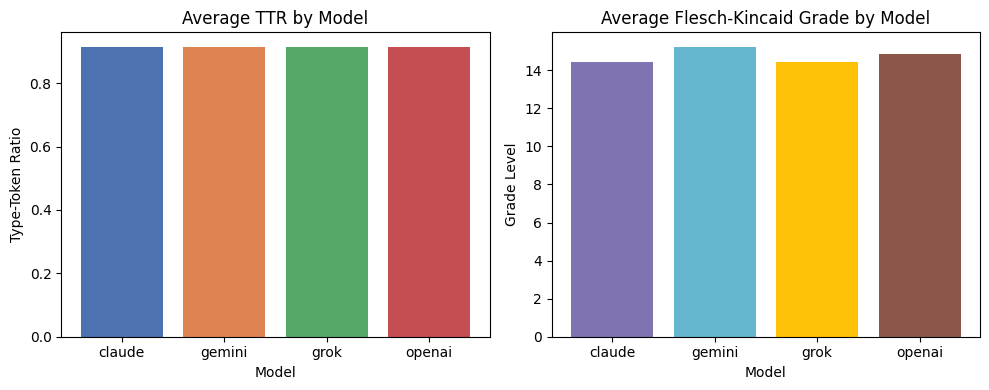

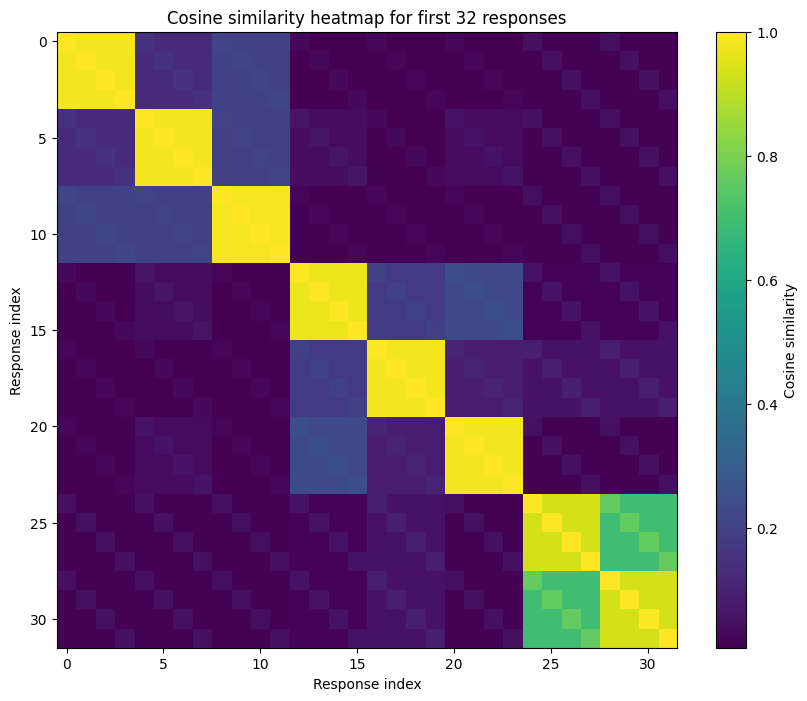

In [13]:
import matplotlib.pyplot as plt

display_columns = ["question_id", "figure", "model", "word_count", "unique_word_count", "ttr", "flesch_kincaid_grade"]

def safe_print_df(df_obj, **kwargs):
    try:
        print(df_obj.to_markdown(**kwargs))
    except Exception:
        print(df_obj.to_string(**kwargs))

safe_print_df(df[display_columns].head(10), index=False)

model_summary = df.groupby("model").agg(
    responses=("response", "size"),
    avg_ttr=("ttr", "mean"),
    avg_grade=("flesch_kincaid_grade", "mean"),
    avg_word_count=("word_count", "mean"),
).reset_index()
print("Model summary:")
safe_print_df(model_summary, index=False)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(model_summary["model"], model_summary["avg_ttr"], color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
plt.title("Average TTR by Model")
plt.ylabel("Type-Token Ratio")
plt.xlabel("Model")

plt.subplot(1, 2, 2)
plt.bar(model_summary["model"], model_summary["avg_grade"], color=["#8172B2", "#64B5CD", "#FFC107", "#8C564B"])
plt.title("Average Flesch-Kincaid Grade by Model")
plt.ylabel("Grade Level")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

sample_size = min(32, len(df))
plt.figure(figsize=(10, 8))
plt.imshow(cosine_matrix[:sample_size, :sample_size], cmap="viridis", aspect="auto")
plt.colorbar(label="Cosine similarity")
plt.title(f"Cosine similarity heatmap for first {sample_size} responses")
plt.xlabel("Response index")
plt.ylabel("Response index")
plt.show()


## Next steps

- The dummy dataset is now built from the full 42-question bank, so analysis reflects a more realistic distribution of questions and models.
- Replace `data/responses/dummy_full.jsonl` with real model outputs once the full collection completes.
- The code can be adapted to compute pairwise similarity by question, model, or figure as needed.
